<a href="https://colab.research.google.com/github/Abhiramkumarsoni/hotel-price-prediction/blob/main/Implementing_YOLO_V4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TRAIN A CUSTOM YOLOv4 OBJECT DETECTOR🧪📖📋**

(TUTORIAL FOR BEGINNERS)

### **In this tutorial, we will be training a custom detector for mask detection using YOLOv4 and Darknet**


/content/yolov4.png

### **FOLLOW THESE 11 STEPS TO TRAIN AN OBJECT DETECTOR USING YOLOv4**

<ins>**NOTE**</ins>: If you get disconnected or lose your session for some reason you have to run steps 2, 5, and 6 again to mount the drive, edit makefile and build darknet every single time, otherwise the darknet executable will not work.

 # **👨🏻‍🎓Session flow👨🏻‍🎓**

👉 1. **Create *`yolov4`* and *`training`* folders in your drive**

👉 2. **Step 2: Configure our GPU environment on Google Colab and Mount drive**

👉 3. **Clone `darknet` git repository**

👉 4. **Create & upload the files which we need for training a custom detector**

👉 5. **Make changes in the `makefile` to enable OPENCV and GPU**

👉 6. **Run `make` command to build darknet**

👉7. **Copy all the files from the *`yolov4`* folder to the darknet directory**

👉 8. **Run the *`process.py`* python script to create the *`train.txt`* & *`test.txt`* files inside the *data* folder**

👉 9. **Download the pre-trained *`yolov4`* weights**

👉 10. **TRAINING**

👉 11. **Test your custom Object Detector**




#**📖Introduction📖**

YOLO-V4 stands for "You Only Look Once - Version 4" is a state of art real time object detection model🧩🧪.

 It is build upon the previous versions of YOLO. The field of computer vision was completely transformed by the innovative real-time object identification technology known as YOLO (You Only Look Once).



- The first introduction of it came from Joseph Redmon et al. in their 2016 work "You Only Look Once: Unified, Real-Time Object Detection."🧩💻
- By treating the issue as a single regression problem and predicting bounding boxes and class probabilities straight from entire images in a single evaluation, 🛠️🧪YOLO provides an incredibly effective method for object detection in photos or videos.
- On 2020, Alexey Bochkovskiy, also known as AlexeyAB on Github, Chien-Yao Wang, and Hong-Yuan Mark Liao, released the most recent version 4.
- The primary objective 🏆⚡️ was to create a more rapid and precise object detector that could be trained and evaluated on any standard GPU in order to produce findings that were persuasive, high-quality, and real-time🛠️🔍💻.
- It operates by dividing the task of object identification into two parts: classification to ascertain the class of the object and regression to identify object location using bounding boxes.🔍📚



## Prerequisite

In [ ]:
!sudo find /usr/ -name 'libcuda.so.*'

/usr/local/cuda-12.2/compat/libcuda.so.535.129.03
/usr/local/cuda-12.2/compat/libcuda.so.1
/usr/lib64-nvidia/libcuda.so.1
/usr/lib64-nvidia/libcuda.so.535.104.05


In [ ]:
import os

# Set the directory path where libcuda.so.1 is located
cuda_lib_path = '/usr/local/cuda-12.2/compat'
current_ld_library_path = os.environ.get('LD_LIBRARY_PATH', '')
new_ld_library_path = f"{cuda_lib_path}:{current_ld_library_path}"

# Update the environment variable
os.environ['LD_LIBRARY_PATH'] = new_ld_library_path
print("Updated LD_LIBRARY_PATH:", os.environ['LD_LIBRARY_PATH'])

Updated LD_LIBRARY_PATH: /usr/local/cuda-12.2/compat:/usr/lib64-nvidia


In [ ]:
!echo $LD_LIBRARY_PATH

/usr/local/cuda-12.2/compat:/usr/lib64-nvidia


In [ ]:
# !ldconfig -p | grep libcuda.so.1

#Here is the step by step procedure for implementing YOLO-V4 on a custom dataset.

# **Step 1: Create *`yolov4`* and *`training`* folders in your drive**

 Create a folder named ***yolov4*** in your drive in the root folder itself (My Drive)

 Next, create another folder named ***training*** inside the ***yolov4*** folder. This is where we will save our trained weights (This path is mentioned in the ***obj.data*** file which we will upload later)


## **Step 2: Configure our GPU environment on Google Colab and Mount drive**

- Go to the Runtime menu and select Change runtime type.

- Choose GPU from the Hardware accelerator dropdown menu.
Click SAVE.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Navigate to /mydrive/yolov4 folder

In [2]:
%cd /content/drive/MyDrive/yolov4Alma/

/content/drive/MyDrive/yolov4Alma


In [3]:
# Checking if the current directory is the same as /content/drive/MyDrive/yolov4Alma
import os
print(os.getcwd())

/content/drive/MyDrive/yolov4Alma


In [4]:
%ls

darknet/  obj.names  process.py  yolov4-custom.cfg
obj.data  obj.zip    training/


## **Step 3: Installing Darknet for YOLOv4 on Colab**

- Clone Darknet git repository

Darknet is an open source neural network framework written in C and CUDA and serves as the basis for YOLO. It is fast, easy to install, and supports CPU and GPU computation.

In [5]:
#we clone the fork of darknet and small changes have been made to configure darknet for training
!git clone https://github.com/AlexeyAB/darknet

fatal: destination path 'darknet' already exists and is not an empty directory.


In [18]:
%ls

3rdparty/               data/                   net_cam_v4.sh*
backup/                 docker-compose.yml      obj/
build/                  Dockerfile.cpu          package.xml
CCM/                    Dockerfile.gpu          README.md
cfg/                    image_yolov3.sh*        results/
cmake/                  image_yolov4.sh*        scripts/
CMakeLists.txt          include/                src/
DarknetConfig.cmake.in  json_mjpeg_streams.sh*  vcpkg.json
darknet_images.py       LICENSE                 video_yolov3.sh*
darknet.py              Makefile                video_yolov4.sh*
darknet_video.py        net_cam_v3.sh*


In [7]:
%cd /content/drive/MyDrive/yolov4Alma/darknet/

/content/drive/MyDrive/yolov4Alma/darknet


# **Step 4: Create & upload the following files which we need for training a custom detector**


a.   `Labeled Custom Dataset`

b.   `Custom cfg file`

c.   `obj.data and obj.names files`

d.   `process.py file (to create train.txt and test.txt files for training)`


**I have uploaded my custom files on [yolov4Alma](https://drive.google.com/drive/folders/1T6JQqiBj1gLXfS2Fk3Q9aVjADAGaoWG8?usp=drive_link).
I am working with 2 classes i.e. dogs and cats**




- **Step 4(a): Upload the Labeled custom dataset *`obj.zip`* file to the *`yolov4`* folder on your drive**


Create the zip file **obj.zip** from the **obj** folder containing both the input image ".jpg" files and their corresponding YOLO format labeled ".txt" files.

Upload the zip file to the ***yolov4*** folder on your drive.

Each of the jpeg file will have its corresponding txt file containing:

The label file will contain normalized values for all 5 parameters so their values will be between 0 to 1. The label for one object looks like as shown below.

`<object-class> <x_center> <y_center> <width> <height>`

Where:

- `<object-class>` - integer number for an object from 0 to (classes-1)

- `<x_center> <y_center> <width> <height>` - float values relative to width and height of the image, will be between 0.0 to 1.0



To know more about collecting datasets and labeling, read this [Medium article](https://medium.com/@techzizou007/image-dataset-labeling-annotation-bec3390eda2d).


Blog for all the Data Labellers: https://github.com/HumanSignal/awesome-data-labeling?tab=readme-ov-file

- **Step 4(b): Create your custom *`config`* file and upload it to your drive**

Download the **yolov4-custom.cfg** file from ***darknet/cfg*** directory, make changes to it, and upload it to the ***yolov4*** folder on your drive .

You can also download the custom config file from the official [AlexeyAB Github](https://www.github.com/AlexeyAB/darknet)


**You need to make the following changes in your custom config file:**

*   change line batch to batch=64
*   change line subdivisions to subdivisions=16
*   change line max_batches to (classes*2000 but not less than number of training images and not less than 6000), f.e. max_batches=6000 if you train for 3 classes
*    change line steps to 80% and 90% of max_batches, f.e. steps=4800,5400
*    set network size width=416 height=416 or any value multiple of 32
*    change line classes=80 to your number of objects in each of 3 [yolo]-layers
*    change [filters=255] to filters=(classes + 5)x3 in the 3 [convolutional] before each [yolo] layer, keep in mind that it only has to be the last [convolutional] before each of the [yolo] layers.
     So if classes=1 then it should be filters=18. If classes=2 then write filters=21.



**Step 4(c): Create your *`obj.data`* and *`obj.names`* files and upload to your drive**



**obj.data**

```
classes = 2
train = data/train.txt
valid = data/test.txt
names = data/obj.names
backup = /content/drive/MyDrive/yolov4/training
# make sure the yolov4 is the folder we've have created in my case i have assigined yolov4Alma

```

**obj.names**

```
cat
dog
```

**Step 4(d): Upload the *`process.py`* script file to the *`yolov4`* folder on your drive**

We will run process.py in the 8th step for creating testing and training files. Step 8 will be explainining on the relevance of process.py file.

In [16]:
# list contents in yolov4 folder in your drive
!ls /content/drive/MyDrive/yolov4Alma

darknet   obj_format.data  obj.zip     training
obj.data  obj.names	   process.py  yolov4-custom.cfg


**Step 5: Make changes in the `makefile` to enable OPENCV and GPU**

although it is already there but we always need to downloaded and uploaded in the drive

go to this github and download makefile under the darknet: https://github.com/AlexeyAB/darknet/blob/master/Makefile

---



In [19]:
#install environment from the Makefile
# change makefile to have GPU and OPENCV enabled
# also set CUDNN, CUDNN_HALF and LIBSO to 1

%cd /content/drive/MyDrive/yolov4Alma/darknet/
!sed -i 's/OPENCV=0/OPENCV=1/' Makefile  # it searches for the string OPENCV=0 in the Makefile and replaces it with OPENCV=1.
!sed -i 's/GPU=0/GPU=1/' Makefile   # replaces GPU=0 with GPU=1 in the Makefile.
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile  # to enable the use of cuDNN (CUDA Deep Neural Network library) in the darknet framework.
!sed -i 's/CUDNN_HALF=0/CUDNN_HALF=1/' Makefile # to enable Tensor Core operations in cuDNN.
!sed -i 's/LIBSO=0/LIBSO=1/' Makefile  # compile darknet as a shared library (.so file) instead of a standalone executable.

/content/drive/MyDrive/yolov4Alma/darknet


**NOTE**


      !sed -i 's/OPENCV=0/OPENCV=1/' Makefile
- When you set OPENCV=1 in the Makefile, you are telling the darknet build system to include support for OpenCV. This means that darknet will be able to utilize OpenCV's functions for tasks such as loading images and videos, which can be useful for training and testing deep learning models on image and video data. Without enabling OpenCV support (OPENCV=0), darknet would rely on its own image processing routines, which may be less efficient or lacking in certain functionalities compared to OpenCV.


      !sed -i 's/GPU=0/GPU=1/' Makefile
- When you set GPU=1 in the Makefile, you're instructing the darknet build system to compile the code with GPU support. This means that darknet will utilize the computational power of a GPU (Graphics Processing Unit) for training and inference tasks, which can significantly accelerate the process compared to running solely on a CPU.


      !sed -i 's/CUDNN=0/CUDNN=1/' Makefile
- cuDNN is a GPU-accelerated library of primitives for deep neural networks, developed by NVIDIA. When you set CUDNN=1 in the Makefile, you're indicating to the darknet build system to enable cuDNN support. This allows darknet to use the optimized cuDNN implementations for its neural network operations, resulting in faster training and inference times compared to using generic GPU implementations or CPU-based computations.


      !sed -i 's/CUDNN_HALF=0/CUDNN_HALF=1/' Makefile
- Tensor Cores are specialized hardware units available in certain NVIDIA GPUs that are designed to accelerate specific types of tensor operations commonly found in deep learning workloads. When you set CUDNN_HALF=1 in the Makefile, you're instructing cuDNN to use half-precision (FP16) data types for computations wherever possible. Half-precision arithmetic can lead to faster computations and reduced memory usage compared to single-precision (FP32) arithmetic, especially when utilizing Tensor Cores on compatible GPUs.


      !sed -i 's/LIBSO=0/LIBSO=1/' Makefile
- In the context of building darknet, setting LIBSO=1 in the Makefile instructs the build system to generate a shared library version of the darknet executable. A shared library, also known as a dynamic link library (DLL) on Windows or shared object (SO) on Unix-like systems, contains code and data that can be used by multiple programs simultaneously. By creating a shared library, darknet's functionality becomes encapsulated in a single file that can be linked to and utilized by other programs or libraries.

**Step 6: Run `make` command to build darknet**

Running the make command for building darknet (or any software project) is essential because it initiates the build process according to the instructions provided in the Makefile.


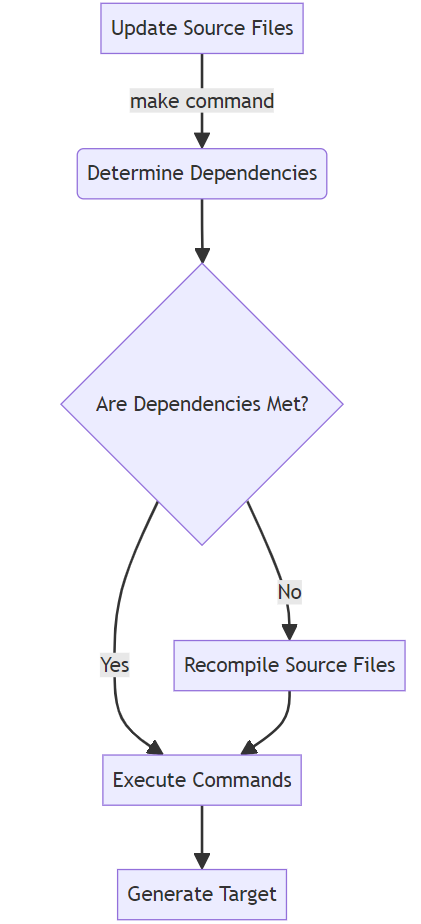


In [22]:
!apt update
!apt install -y libopencv-dev pkg-config

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,945 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,070 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:13 https://ppa.launchpadcontent.net/deadsnakes/p

In [23]:
!pkg-config --modversion opencv4

4.5.4


In [24]:
!make

chmod +x *.sh
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DOPENCV `pkg-config --cflags opencv4 2> /dev/null || pkg-config --cflags opencv` -DGPU -I/usr/local/cuda/include/ -DCUDNN -DCUDNN_HALF -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DOPENCV -DGPU -DCUDNN -I/usr/local/cudnn/include -DCUDNN_HALF -fPIC -c ./src/image_opencv.cpp -o obj/image_opencv.o
./src/image_opencv.cpp: In function ‘void draw_detections_cv_v3(void**, detection*, int, float, char**, image**, int, int)’:
./src/image_opencv.cpp:945:23: warning: variable ‘rgb’ set but not used []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-but-set-variable-Wunused-but-set-variable]8;;]
  945 |                 float rgb[3];
      |                       ^~~
./src/image_opencv.cpp: In function ‘void cv_draw_object(image, float*, int, int, int*, float*, int*, int, char**)’:
./src/image_opencv.cpp:1443:14: warning: unused variable ‘buff’ []8;;https:/

If not working try this:

    !make clean && make GPU=1

In [25]:
#!make clean && make GPU=1

The command !make typically invokes the make utility in Unix-like environments, which reads the Makefile in the current directory and executes the default target specified therein. However, sometimes simply running make may not be sufficient for rebuilding a project, especially if there have been changes to the project configuration or dependencies.

- make clean: This command removes all generated files, ensuring a clean slate for the build process. It's useful for clearing out any stale files from previous builds.

- make GPU=1: This command rebuilds the project with GPU support enabled, as specified by setting the GPU variable to 1. This ensures that the project is compiled with the necessary GPU-related configurations.

##**Step 7: Copy all the files from the *`yolov4`* folder to the darknet directory**

7(a) Copy the obj.zip file from your drive into the darknet directory and unzip it into the data folder in the Colab VM

7(b) Copy your yolov4-tiny-custom.cfg file so that it is now in /darknet/cfg/ folder in the Colab VM

7(c) Copy the obj.names and obj.data files so that they are now in /darknet/data/ folder in the Colab VM

7(d) Copy the process.py file into the current darknet directory in the Colab VM



In [26]:
import os
print(os.getcwd())

/content/drive/MyDrive/yolov4Alma/darknet


The current working directory is /darknet



go to the darknet/cfg and detelete everything 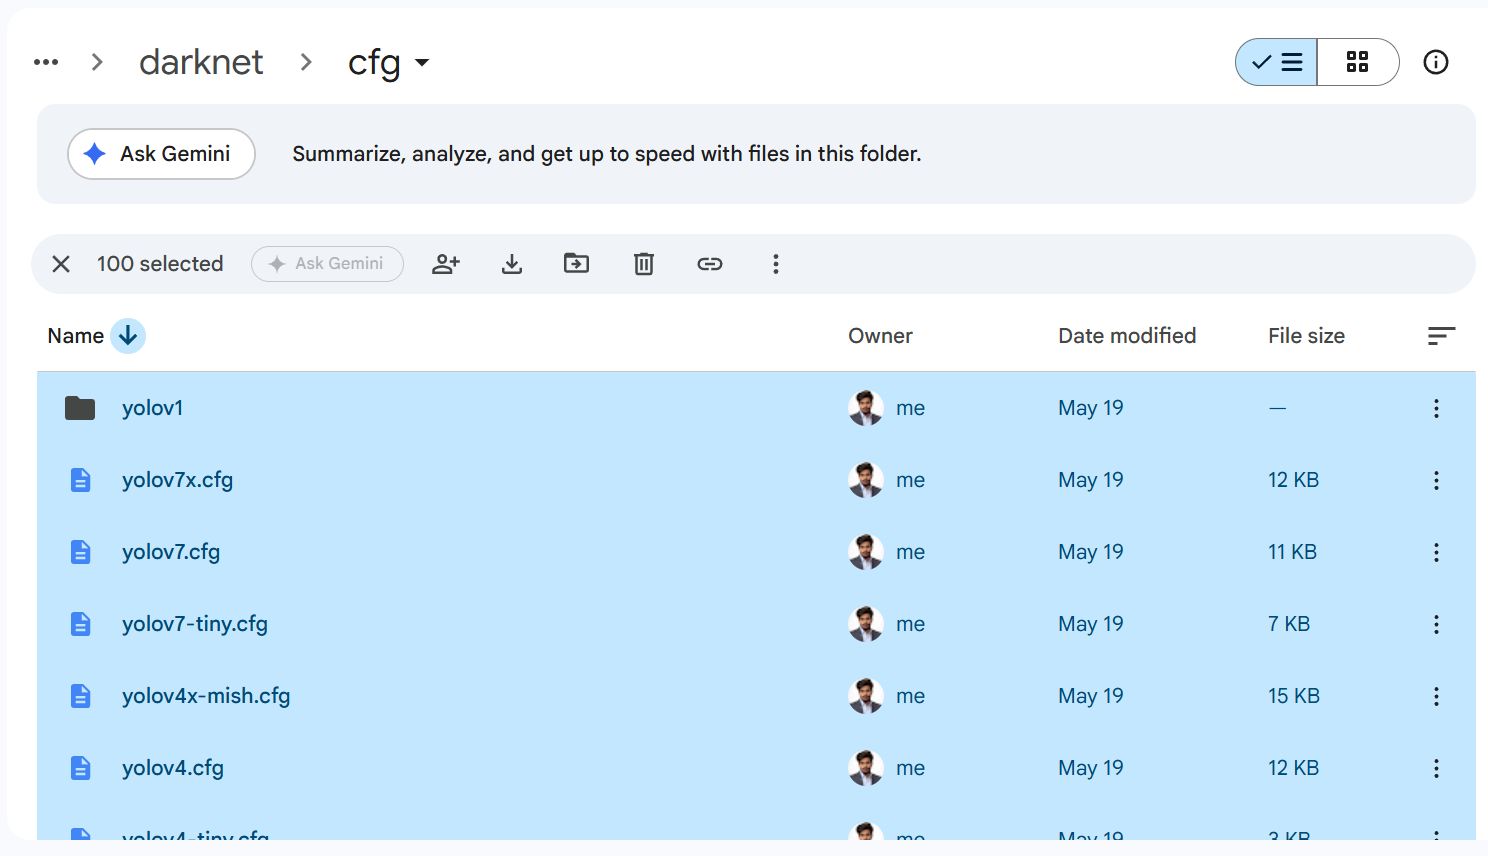

Similarly go to the darknet/data folder and keep label and delete everything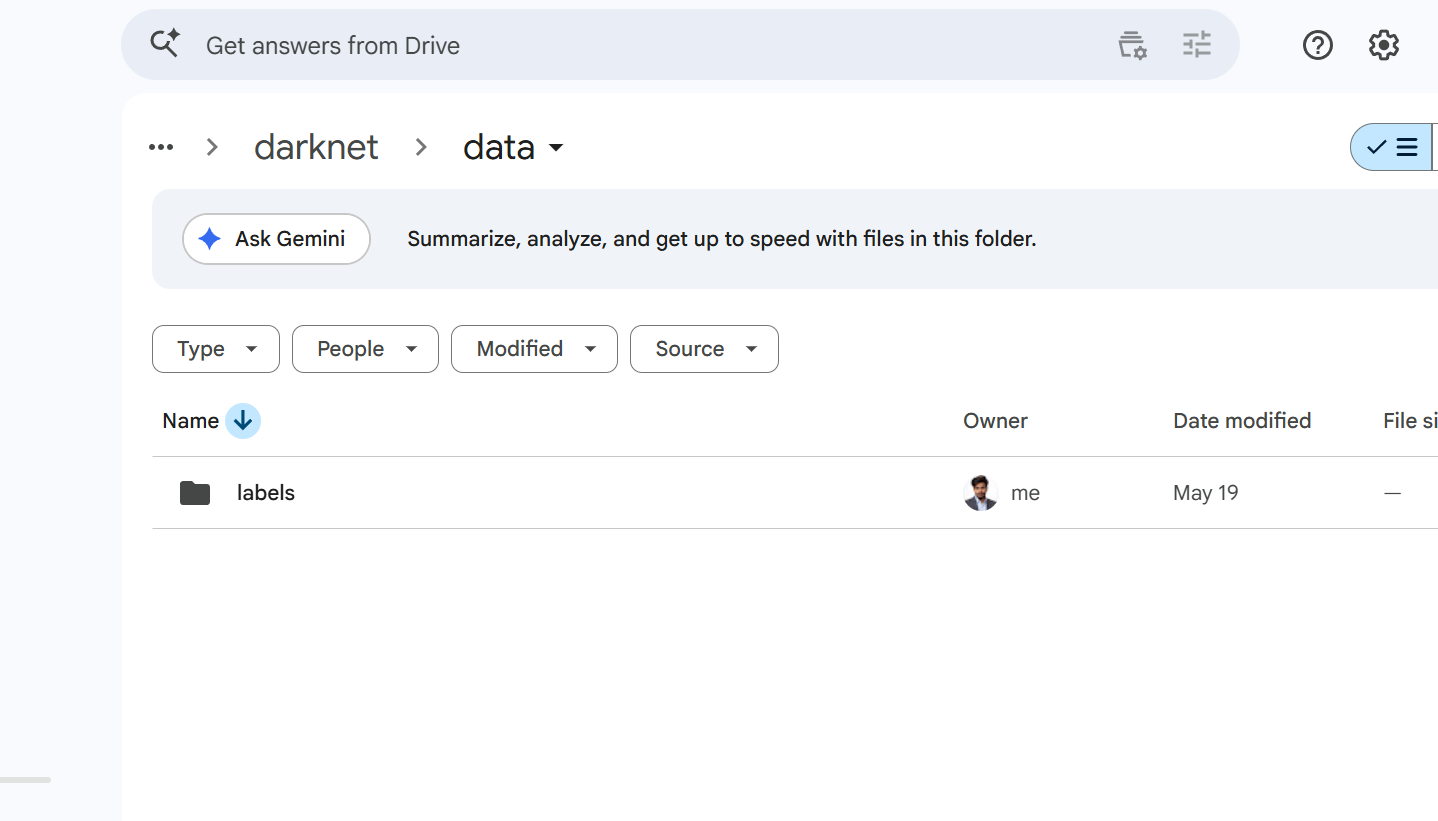

In [ ]:
#This step is optional.
# Clean the data and cfg folders first except the labels folder in data which is required
#So just remove all other files from the data folder and completely clean the cfg folder as we already have our custom config file in the yolov4 folder

# %cd data/
# !find -maxdepth 1 -type f -exec rm -rf {} \;
# %cd ..

# %rm -rf cfg/
# %mkdir cfg

/content/drive/MyDrive/yolov4/darknet/data
/content/drive/MyDrive/yolov4/darknet


7(a) Copy the obj.zip file from your drive into the darknet directory and unzip it into the data folder in the Colab VM



Unzip the obj file and upload it on data in darknet folder

In [27]:
#copy the datasets zip file to the root darknet folder
!cp  /content/drive/MyDrive/yolov4Alma/obj.zip ./data/

In [28]:
# unzip the datasets and their contents so that they are now in /darknet/data/ folder
!unzip /content/drive/MyDrive/yolov4Alma/obj.zip -d data/

Archive:  /content/drive/MyDrive/yolov4Alma/obj.zip
   creating: data/obj/
  inflating: data/obj/pexels-artem-makarov-289670876-13224731_jpg.rf.41f22d3cea8276286a75e28929dc6572.jpg  
  inflating: data/obj/pexels-artem-makarov-289670876-13224731_jpg.rf.41f22d3cea8276286a75e28929dc6572.txt  
  inflating: data/obj/pexels-artem-makarov-289670876-13224731_jpg.rf.6f0be4959e685760dcfa4cb553be8b82.jpg  
  inflating: data/obj/pexels-artem-makarov-289670876-13224731_jpg.rf.6f0be4959e685760dcfa4cb553be8b82.txt  
  inflating: data/obj/pexels-artem-makarov-289670876-13224731_jpg.rf.cf7b87ded03bedd2597ace7cbfa45866.jpg  
  inflating: data/obj/pexels-artem-makarov-289670876-13224731_jpg.rf.cf7b87ded03bedd2597ace7cbfa45866.txt  
  inflating: data/obj/pexels-berkaynb-10889054_jpg.rf.046ece099527473e4709f7cd193bef30.jpg  
  inflating: data/obj/pexels-berkaynb-10889054_jpg.rf.046ece099527473e4709f7cd193bef30.txt  
  inflating: data/obj/pexels-berkaynb-10889054_jpg.rf.560fdfdeaa0e4f67fe2429ff75408d94.jpg 

Rename the file name to obj

7(b) Copy your yolov4-custom.cfg file so that it is now in /darknet/cfg/ folder in the Colab VM



In [29]:
!cp /content/drive/MyDrive/yolov4Alma/yolov4-custom.cfg cfg

7(c) Copy the obj.names and obj.data files so that they are now in /darknet/data/ folder in the Colab VM



In [30]:
# Copy the obj.names and obj.data files from your drive so that they are now in /darknet/data/ folder

!cp /content/drive/MyDrive/yolov4Alma/obj.names data
!cp /content/drive/MyDrive/yolov4Alma/obj.data  data

7(d) Copy the process.py file into the current darknet directory in the Colab VM



In [31]:
# Copy the process.py file to the current darknet directory

!cp /content/drive/MyDrive/yolov4Alma/process.py .

## **Step 8: Run the *`process.py`* python script to create the *`train.txt`* & *`test.txt`* files inside the *data* folder**



**To divide all image files into 2 parts. 90% for train and 10% for test.**

This *`process.py`* script creates the files *`train.txt`* & *`test.txt`* where the *`train.txt`* file has paths to 90% of the images and *`test.txt`* has paths to 10% of the images.

You can download the ***`process.py`*** script from [GitHub](https://github.com/techzizou/yolov4-custom_Training/tree/main/yolov4)

In [32]:
!python process.py

/content/drive/MyDrive/yolov4Alma/darknet


In [ ]:
# list the contents of data folder to check if the train.txt and test.txt files have been created
!ls data/

labels	obj  obj.data  obj.names  obj.zip  test.txt  train.txt


## **Step 9: Download the pre-trained *`yolov4`* weights**

**Why pre trained?**

- Pre-trained weights provide a starting point for training the YOLOv4 model on a new dataset or task. Instead of training the model from scratch, which can be computationally expensive and time-consuming, you can initialize the model with weights learned from training on a large dataset. This process is known as transfer learning.

In [33]:
# Download the yolov4 pre-trained weights file
!wget https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.conv.137

--2026-05-21 08:14:35--  https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.conv.137
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/75388965/48bfe500-889d-11ea-819e-c4d182fcf0db?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-21T09%3A06%3A51Z&rscd=attachment%3B+filename%3Dyolov4.conv.137&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-21T08%3A05%3A58Z&ske=2026-05-21T09%3A06%3A51Z&sks=b&skv=2018-11-09&sig=KMLB5xC5EBRWZEEiucuwksgSEWJGNwffxaPan%2FVLIzY%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3OTM1NDg3NSwibmJmIjoxNzc5MzUxMjc1LCJwYXRoIjoicmVsZWFzZWFzc2V

In [34]:
!ls /content/drive/MyDrive/yolov4Alma/darknet

3rdparty		darknet.py	       libdarknet.so  scripts
backup			darknet_video.py       LICENSE	      src
build			data		       Makefile       uselib
CCM			docker-compose.yml     net_cam_v3.sh  vcpkg.json
cfg			Dockerfile.cpu	       net_cam_v4.sh  video_yolov3.sh
cmake			Dockerfile.gpu	       obj	      video_yolov4.sh
CMakeLists.txt		image_yolov3.sh        package.xml    yolov4.conv.137
darknet			image_yolov4.sh        process.py
DarknetConfig.cmake.in	include		       README.md
darknet_images.py	json_mjpeg_streams.sh  results


# **Step 10: TRAINING**

**Train your custom detector**

For best results, you should stop the training when the average loss is less than 0.05 if possible or at least below 0.3, else train the model until the average loss does not show any significant change for a while.

In [ ]:
# !nvcc --version

In [ ]:
# import os
# os.environ['LD_LIBRARY_PATH'] += ':/usr/local/cuda/lib64'

In [ ]:
# !apt-get update
# !apt-get install -y libcuda1-11-0

In [ ]:
# !ln -s /usr/local/cuda/lib64/stubs/libcuda.so /usr/local/cuda/lib64/stubs/libcuda.so.1
# !echo "/usr/local/cuda/lib64" >> /etc/ld.so.conf.d/cuda.conf
# !ldconfig

In [ ]:
!LD_PRELOAD=/usr/local/cuda-12.2/compat/libcuda.so.1 ./darknet detector train data/obj.data cfg/yolov4-custom.cfg yolov4.conv.137 -dont_show -map

Streaming output truncated to the last 5000 lines.
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 150 Avg (IOU: 0.342055), count: 12, class_loss = 109.627754, iou_loss = 0.398857, total_loss = 110.026611 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 161 Avg (IOU: 0.421030), count: 18, class_loss = 62.315441, iou_loss = 0.175247, total_loss = 62.490688 
 total_bbox = 47340, rewritten_bbox = 0.000000 % 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 139 Avg (IOU: 0.000000), count: 1, class_loss = 150.970947, iou_loss = 0.000000, total_loss = 150.970947 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 150 Avg (IOU: 0.255640), count: 1, class_loss = 109.962738, iou_loss = 0.011322, total_loss = 109.974060 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 161 Avg (IOU: 0.417957), count: 10, class_loss = 60.640720, iou_loss = 0.065952, total_loss = 60.706673 
 total_bbox = 47351, rewritten_bbox

In case you get an error please change the following in the MakeFile and re-run the copy Makefile with the below config:

``` GPU=1
CUDNN=0
CUDNN_HALF=0
OPENCV=1```

to darknet folder and the command !make

In [ ]:
#to restart training your custom detector where you left off(using the weights that were saved last)

# !./darknet detector train data/obj.data cfg/yolov4-custom.cfg /content/drive/MyDrive/yolov4/training/yolov4-custom_last.weights -dont_show -map

In [ ]:
#!./darknet detector train data/obj.data cfg/yolov4-custom.cfg ../training/yolov4.conv.137 -dont_show -map

 CUDA-version: 12020 (12020), cuDNN: 8.9.6, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 Prepare additional network for mAP calculation...
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 16, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    416 x 416 x   3 ->  416 x 416 x  32 0.299 BF
   1 conv     64       3 x 3/ 2    416 x 416 x  32 ->  208 x 208 x  64 1.595 BF
   2 conv     64       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  64 0.354 BF
   3 route  1 		                           ->  208 x 208 x  64 
   4 conv     64       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  64 0.354 BF
   5 conv     32       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  32 0.177 BF
   6 conv     64       3 x 3/ 1    208 x 208 x  32 ->  208 x 208 x  64 1.595 BF
   7 Shortcut Layer: 4,  wt = 0, wn

### **<ins>NOTE</ins>:** If you get disconnected or lose your session for some reason you have to run steps 2, 5, and 6 again to mount the drive, edit makefile and build darknet every single time, otherwise the darknet executable will not work.

**To restart your training (In case the training does not finish and you get disconnected)**

If you get disconnected or lose your session, you don't have to start training your model from scratch again. You can restart training from where you left off. Use the weights that were saved last. The weights are saved every 100 iterations as ***yolov4-custom_last.weights*** in the ***yolov4/training*** folder on your drive. (The path we gave as backup in "obj.data" file).


**So to restart training run only Steps 2, 5, 6 and then run the following command**

## **Step 11: Test your custom Object Detector**

**Make changes to your custom config file**
*   change line batch to batch=1
*   change line subdivisions to subdivisions=1

You can do it either manually or by simply running the code below


    #set your custom cfg to test mode
    %cd cfg
    !sed -i 's/batch=64/batch=1/' yolov4-custom.cfg
    !sed -i 's/subdivisions=16/subdivisions=1/' yolov4-custom.cfg
    %cd ..

In [ ]:
import os
os.getcwd()

'/content/drive/MyDrive/yolov4Alma/darknet'

**Run detector on an image**

In [ ]:
!LD_PRELOAD=/usr/local/cuda-12.2/compat/libcuda.so.1 ./darknet detector test data/obj.data cfg/yolov4-custom.cfg /content/drive/MyDrive/yolov4Alma/training/yolov4-custom_best.weights /content/drive/MyDrive/yolov4Alma/testPics/pet_test_images/pet_img_1.jpg -thresh 0.3

 CUDA-version: 12020 (12020), cuDNN: 8.9.6, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 1, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    416 x 416 x   3 ->  416 x 416 x  32 0.299 BF
   1 conv     64       3 x 3/ 2    416 x 416 x  32 ->  208 x 208 x  64 1.595 BF
   2 conv     64       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  64 0.354 BF
   3 route  1 		                           ->  208 x 208 x  64 
   4 conv     64       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  64 0.354 BF
   5 conv     32       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  32 0.177 BF
   6 conv     64       3 x 3/ 1    208 x 208 x  32 ->  208 x 208 x  64 1.595 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 208 x 208 x  64 0.003 BF
   8 conv   

In [ ]:
# define helper function imShow
def imShow(path):
  import cv2
  import matplotlib.pyplot as plt
  %matplotlib inline

  image = cv2.imread(path)
  height, width = image.shape[:2]
  resized_image = cv2.resize(image,(3*width, 3*height), interpolation = cv2.INTER_CUBIC)

  fig = plt.gcf()
  fig.set_size_inches(18, 10)
  plt.axis("off")
  plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
  #plt.show('')

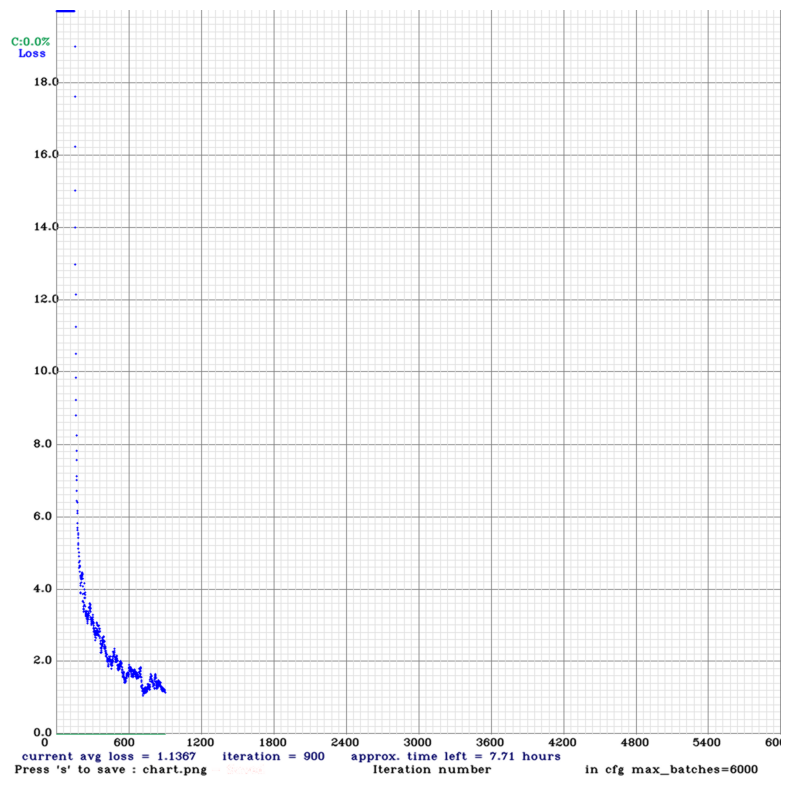

In [ ]:
imShow('chart.png')

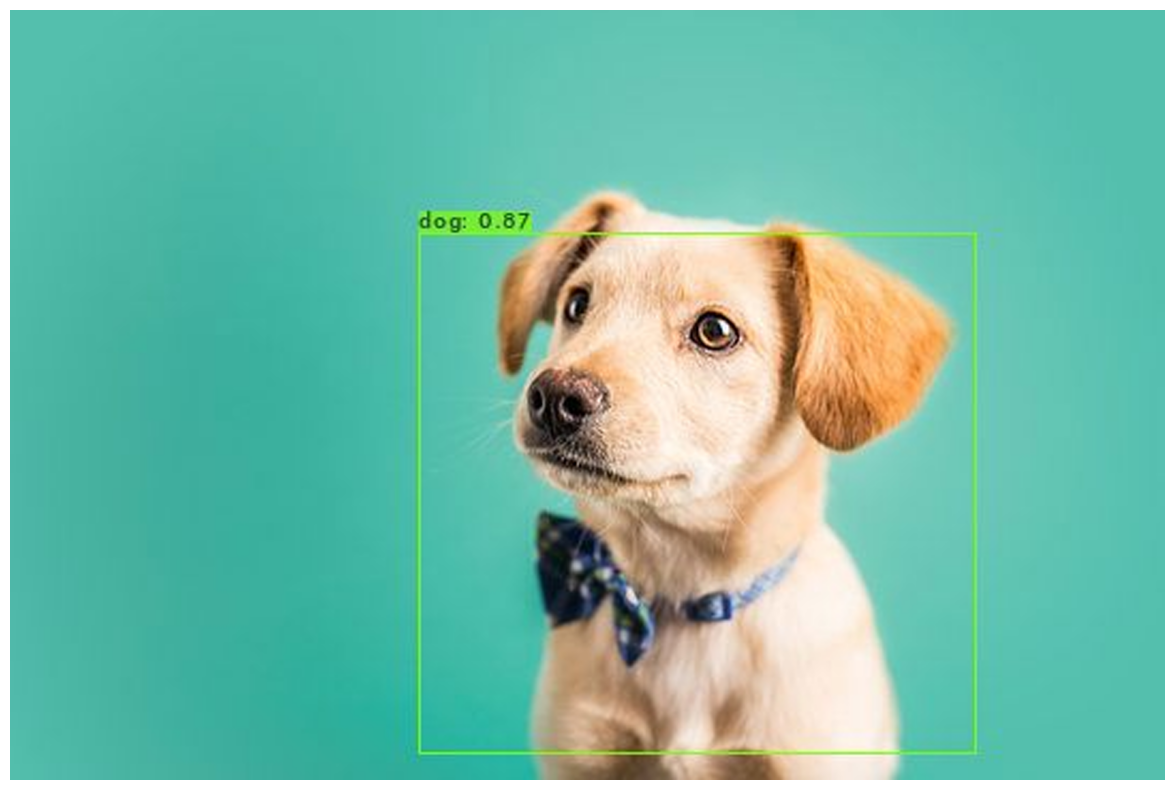

In [ ]:
imShow('predictions.jpg')

#### **Run detector on a video**

In [ ]:
!LD_PRELOAD=/usr/local/cuda-12.2/compat/libcuda.so.1 ./darknet detector demo data/obj.data cfg/yolov4-custom.cfg /content/drive/MyDrive/yolov4Alma/training/yolov4-custom_best.weights -dont_show /content/drive/MyDrive/yolov4Alma/testPics/pet_test_images/dogs.mp4 -i 0 -out_filename /content/drive/MyDrive/yolov4Alma/testPics/pet_test_images/result.avi
# !LD_PRELOAD=/usr/local/cuda-12.2/compat/libcuda.so.1 ./darknet detector test data/obj.data cfg/yolov4-custom.cfg /content/drive/MyDrive/yolov4/training/yolov4-custom_best.weights

Streaming output truncated to the last 5000 lines.
dog: 28% 

FPS:37.6 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 36% 
dog: 28% 

FPS:36.3 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 38% 
dog: 29% 

FPS:36.1 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 43% 

FPS:36.3 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 32% 

FPS:36.7 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:


FPS:37.7 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 25% 

FPS:37.7 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:


FPS:37.1 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 36% 

FPS:37.2 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 54% 
dog: 34% 

FPS:37.7 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 32% 

FPS:37.9 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:


FPS:38.2 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 54% 

FPS:38.3 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 55% 
dog: 33% 

FPS:38.6 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 58% 
dog: 31% 

FPS:38.9 	 AVG_FPS:36.4

 cvWriteFrame 
Objects:

dog: 66% 

FPS

#**Benefits**

- Compared to R-CNN and Fast R-CNN, it is 1000 times faster.
- Accuracy: YOLOv4 maintains high inference speeds while achieving competitive accuracy levels. To increase detection accuracy, it makes use of sophisticated methods including focus loss, spatial attention, and feature pyramid networks (FPNs).
- Model Size: When compared to certain other object identification architectures, YOLOv4's model size is quite small. This facilitates deployment on devices with limited resources, such as smartphones, drones, and edge computing equipment.
- Backbone Architecture: To extract features from input photos efficiently, YOLOv4 makes use of a robust backbone architecture (CSPDarknet53). Contextual information is captured and detection performance is enhanced by this approach.
- Training Efficiency: To increase model generalization and training efficiency, YOLOv4 integrates a number of training strategies, including data augmentation, mixup, and label smoothing. These methods can improve performance on unknown data and accelerate convergence during training.




🖼️ Finding and locating things in an image is the task of object detection in computer vision. Applications for it can be found in many different domains, such as image-based search, surveillance, and autonomous driving. The goal of object detection techniques is to precisely identify and categorize things of interest in pictures.